# [LAB 11] 1. 시계열 데이터의 이해
![alt text](image-1.png)
![alt text](image-2.png)
![alt text](image-3.png)
## #01. 준비작업
### 1. 라이브러리 참조

In [2]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
import numpy as np
from pandas import DataFrame, Series

# 데이터 정상성 확인을 위한 ADF 검정
from statsmodels.tsa.stattools import adfuller

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.31


### 2. 데이터 불러오기

In [3]:
origin = load_data('air_passengers')
origin.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### 3. 시계열 인덱스 설정
- 시계열 분석에서는 날짜/시간 값이 반드시 인덱스로 존재해야 한다.
    - month 컬럼은 이미 datetime64타입이므로 형변환 없이 바로 인덱스로 지정하면 된다.
    - 만약 문자열이라면 to_datetime()으로 먼저 변환해야 한다.

In [4]:
df1 = origin.set_index('Month')

print('인덱스 타입:', type(df1.index))
df1.head()

인덱스 타입: <class 'pandas.DatetimeIndex'>


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## #02. 시계열의 첫 관찰
### 1. 시계열 시각화
- 시계열 분석은 선 그래프에서 시작한다.
- 검정 통계량보다 먼저, 눈으로 세 가지를 확인한다.
    1) 추세 : 1949년 약 100에서 1960년 약 600까지 뚜렷하게 우상향
    2) 계절성 : 매년 같은 모양의 봉우리가 반복 → 주기 12개월(1년) 추정
    3) 변동폭 : 초반에는 봉우리가 낮고 좁지만, 뒤로 갈수록 봉우리가 점점 커진다

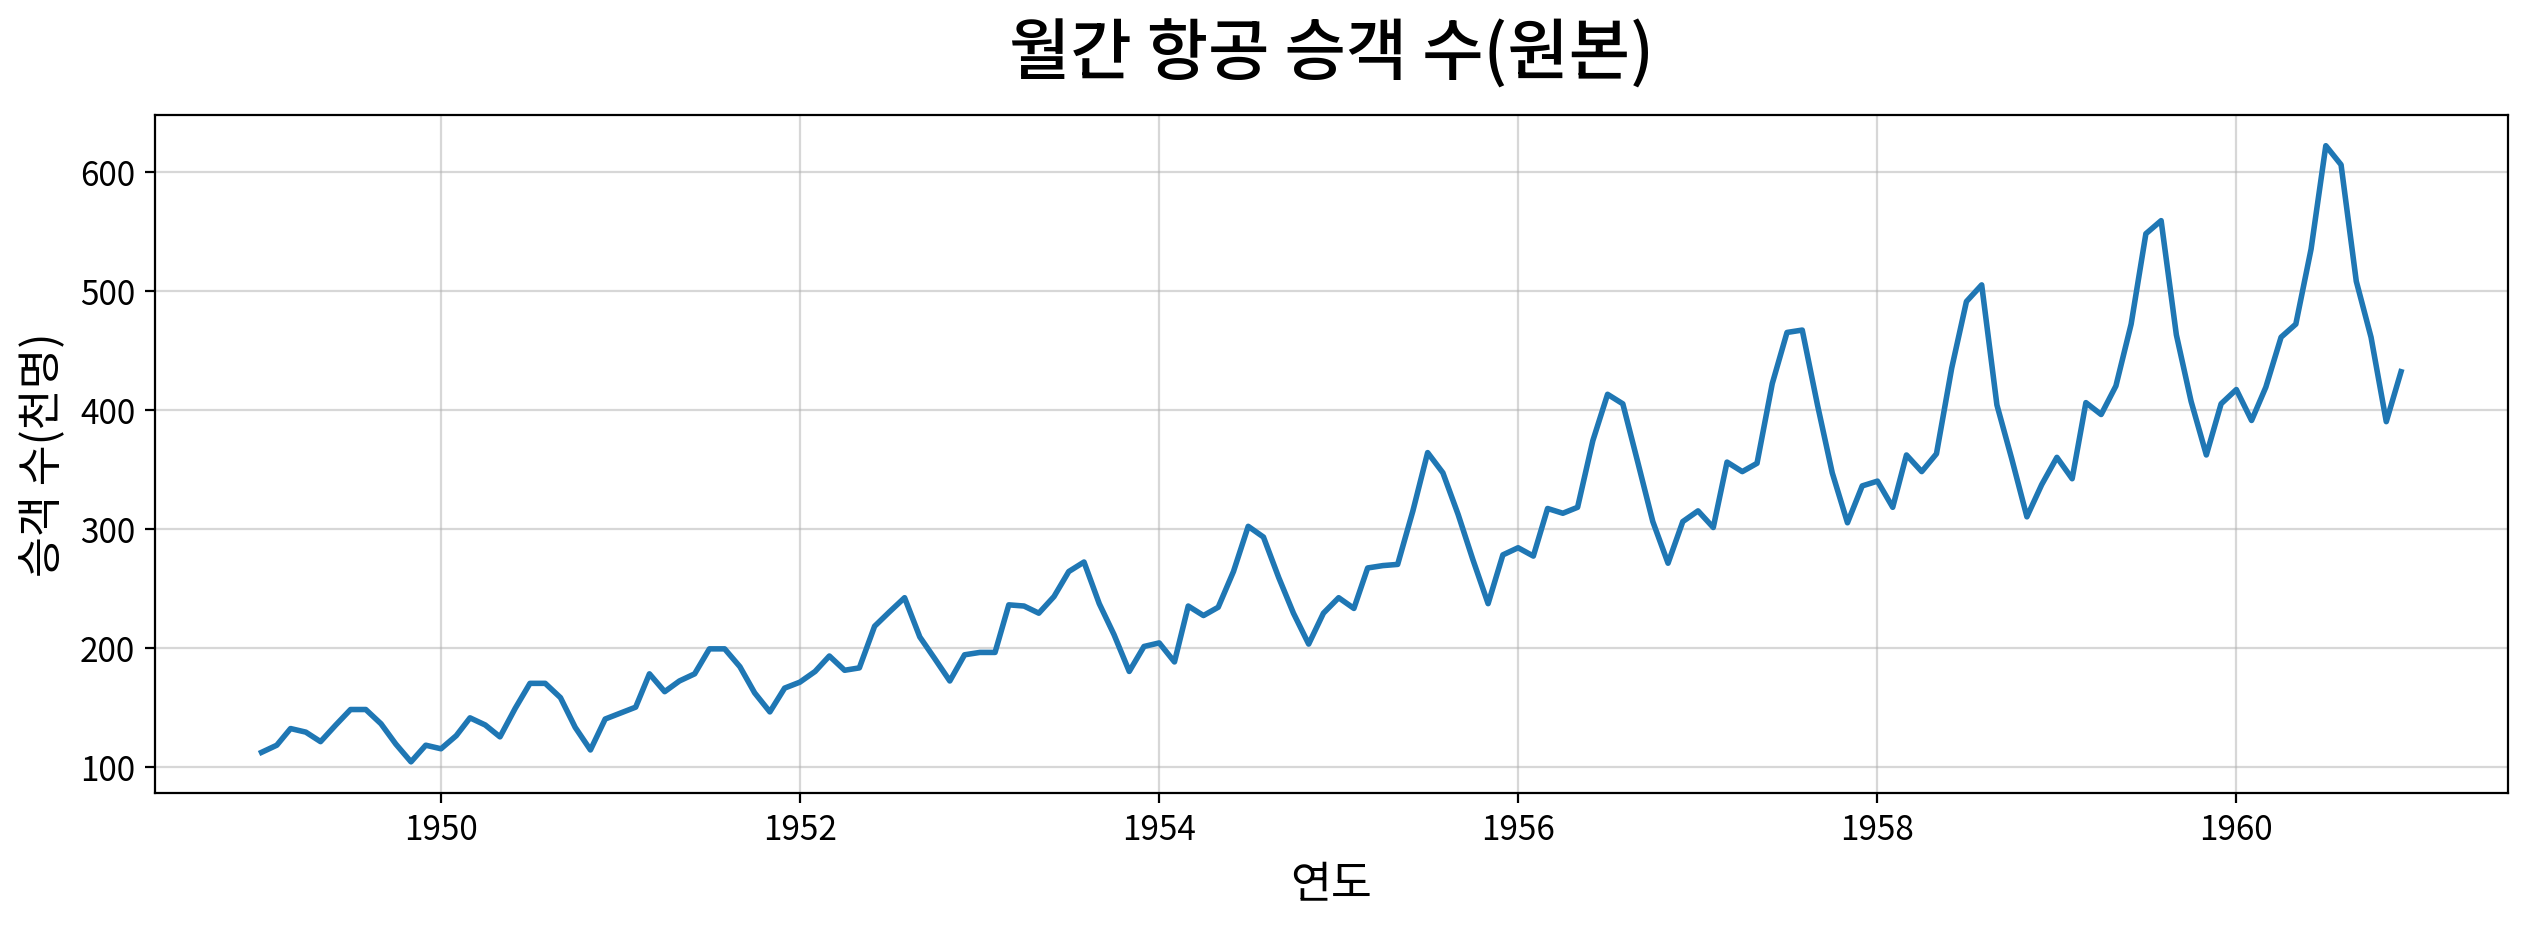

In [5]:
my_plot.lineplot(data=df1, x=df1.index, y='Passengers', title='월간 항공 승객 수(원본)', 
                 xlabel='연도', ylabel='승객 수(천명)', width=1280, height=480)

- 변동폭이 수준(level)에 비례해 커진다(승객 100명일때와 500명 일때의 성수기 증가분은 절대량이 다르다).
→ 이 데이터는 추세+계절성+변동폭 증가 세 가지 문제를 한꺼번에 갖고 있고, 각각 다른 방법으로 해결해야 한다.

## #03. 정상성확인
![alt text](image-4.png)
![alt text](image-5.png)

### 1. 구간을 나눠서 확인하기
- 정상성의 정의가 '어느 구간을 잘라도 비슷하였다'이므로, 실제로 잘라서 비교한다.
    - 여기서는 3개 구간으로 나누다(전체 144건/3 → 48건씩 묶음)
    - 전체 데이터 길이에 대해 나누어 떨어지기만 하면 어느 숫자이건 상관 없음

In [6]:
size = len(df1) // 3 # 데이터를 3개 구간으로 나눔
parts = []

for i in range(3):  # 구간수 만큼 반복
    # 구간의 시작 위치 (0*48, 1*48, 2*48) ~ 끝 위치 (1*48, 2*48, 3*48) 사이를 자름
    part = df1['Passengers'].iloc[i * size : (i + 1) * size]

    # 구간내 평균과 표준편차를 계산하여 리스트에 추가
    parts.append({
        "구간":f"구간 {i+1}",
        "시작": part.index[0].strftime("%Y-%m"),
        '종료': part.index[-1].strftime("%Y-%m"),
        '평균': round(part.mean(),2),
        '표준편차': round(part.std(),2)
    })

DataFrame(parts)

,구간,시작,종료,평균,표준편차
0,구간 1,1949-01,1952-12,158.380,33.090
1,구간 2,1953-01,1956-12,269.040,55.730
2,구간 3,1957-01,1960-12,413.480,78.500


### 2. 이동형균과 이동평쥰편차
- 3개 구간으로 나누는 대신 1년(12개월)짜리 창을 옆으로 밀면서 평균과 표준편차를 계산하면 변화의 모습을 연속적으로 볼 수 있다
    - 3개 구간을 나누는 것과 같은 효과

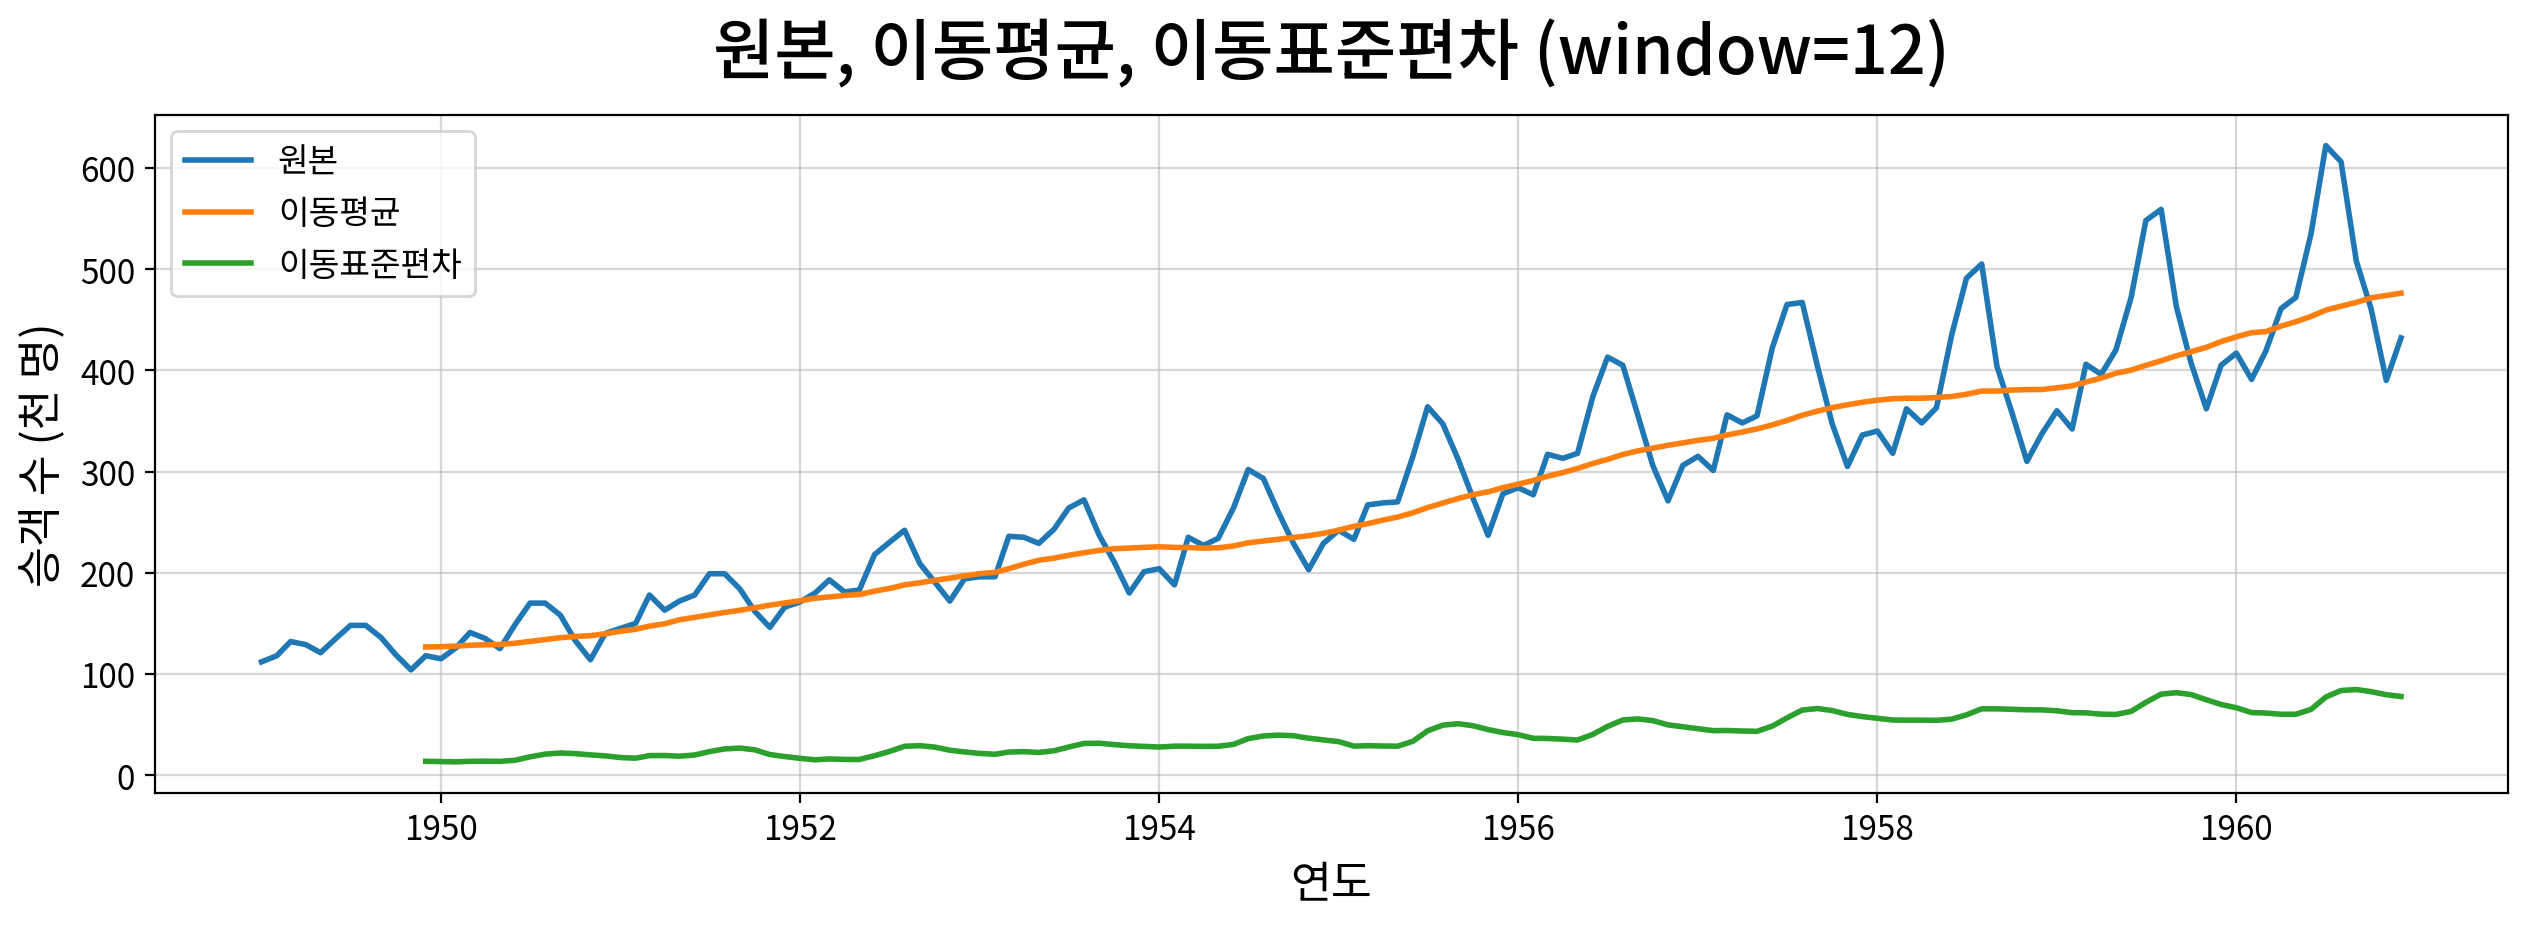

In [7]:
window = 12 # 월간 데이터이므로 1년 =12개월

roll_mean = df1['Passengers'].rolling(window).mean()
roll_std = df1['Passengers'].rolling(window).std()

fig, ax = my_plot.init(width=1280, height=480, title=f'원본, 이동평균, 이동표준편차 (window={window})',
                       xlabel='연도', ylabel='승객 수 (천 명)')

my_plot.lineplot(x=df1.index, y=df1['Passengers'], label='원본', ax=ax)
my_plot.lineplot(x=roll_mean.index, y=roll_mean, label='이동평균', ax=ax)
my_plot.lineplot(x=roll_std.index, y=roll_std, label='이동표준편차', ax=ax)

ax.legend()
my_plot.show()

- 이동편균(주황)이 계속 우상향한다 -> 평균이 일정하지 않다.
- 이동표준편차(초록)도 함께 우상향한다 -> 분산이 일정하지 않다

=> 정상 시계열이라면 두 선 모두 수평선에 가까워야 한다. 이 그래프는 전처리를 할 때마다 다시 그려서 얼마나 수평에 가까워졌는지를 확인하는데 쓴다.
![alt text](image-14.png)

## #04. ADF 검정
### 1. 정상/비정상 샘플 만들기
| 구분 | 의미 | φ 값 | 판정 |
|---|---|---:|---|
| 백색잡음 (White Noise) | 매번 독립적인 난수 | φ = 0 | 정상 |
| 랜덤워크 (Random Walk) | 백색잡음의 누적합 | φ = 1 | 비정상 |

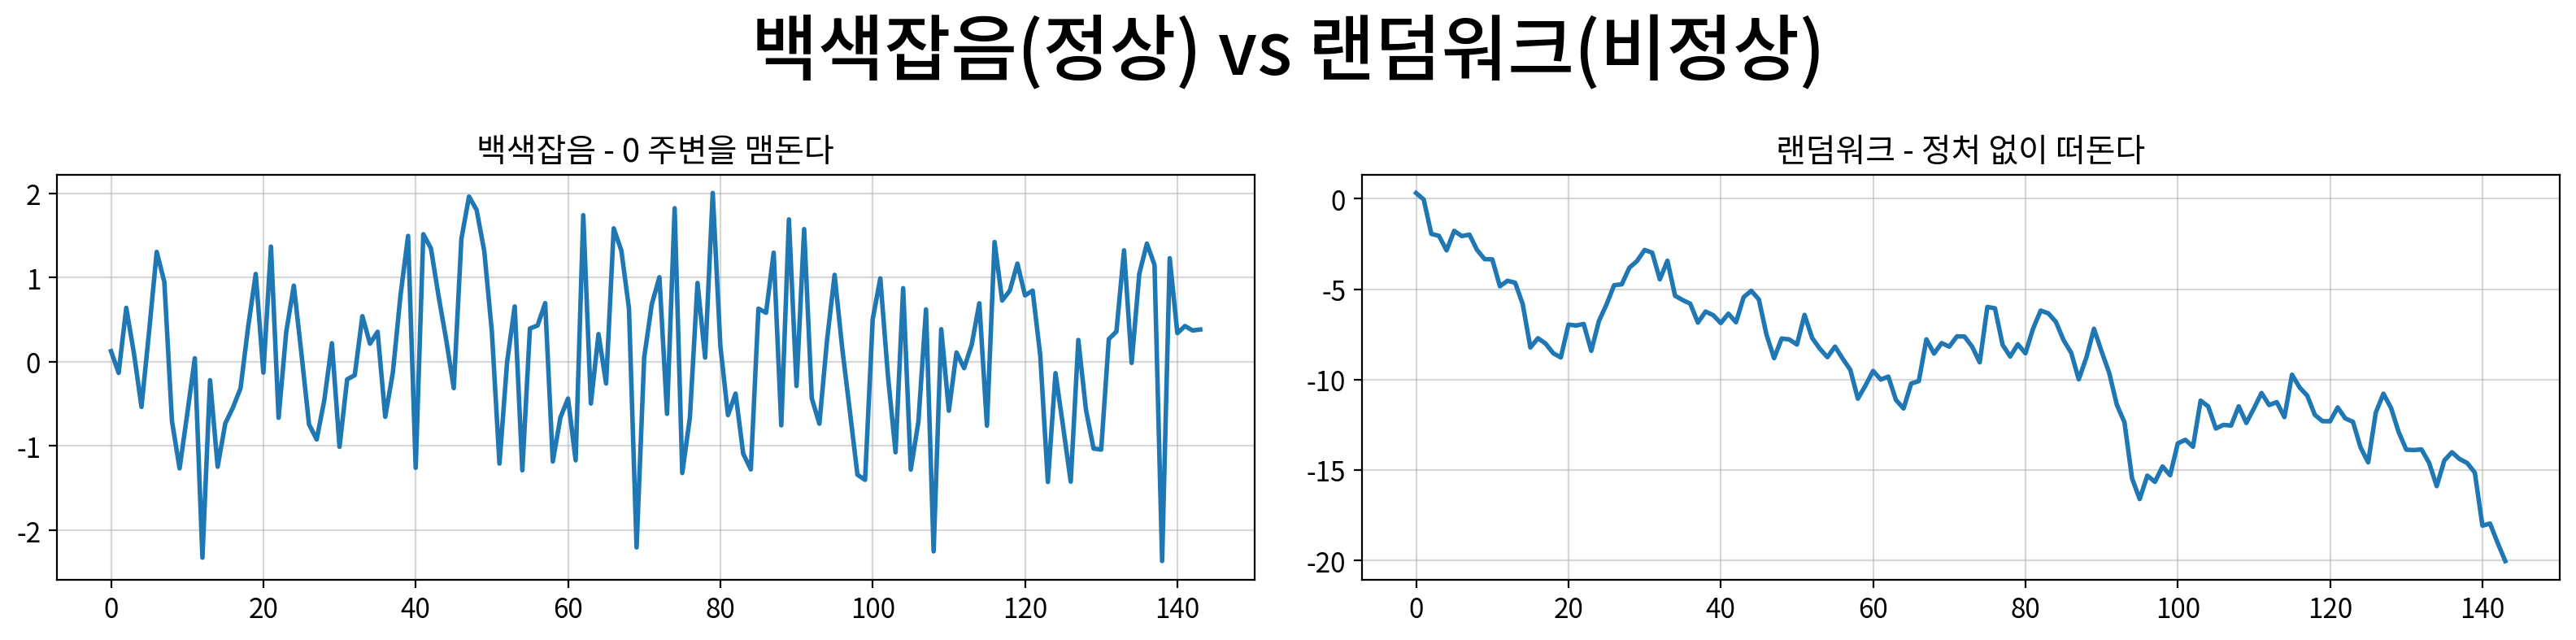

In [8]:
rng = np.random.default_rng(0)  # 결과 재현을 위해 시드 고정

white_noise = rng.normal(0, 1, 144)              # 백색잡음
random_walk = np.cumsum(rng.normal(0, 1, 144))   # 랜덤워크 = 백색잡음의 누적합

fig, ax = my_plot.init(
    rows=1,
    cols=2,
    width=800,
    height=400,
    title="백색잡음(정상) vs 랜덤워크(비정상)"
)

my_plot.lineplot(x=range(144), y=white_noise, ax=ax[0])
ax[0].set_title("백색잡음 - 0 주변을 맴돈다")

my_plot.lineplot(x=range(144), y=random_walk, ax=ax[1])
ax[1].set_title("랜덤워크 - 정처 없이 떠돈다")

my_plot.show()

### 2. 정상성 검정 - 결과를 표로 만드는 함수 정의
- adfuller()는 결과를 튜플로 돌려준다.
    - 몇 번째 무엇이 있는지 매번 외울 수 없으므로, 필요한 값만 뽑아 딕셔너리로 돌려주는 함수를 하나 만들어 두고 이 단원 내내 재사용한다.

In [9]:
def adf_test(data, name):
    x = Series(data).dropna()                 # 결측치 제거
    stat, pvalue, lag, _, crit, _ = adfuller(x)  # ADF 검정 수행

    return {
        "대상": name,
        "관측치 수": len(x),
        "검정통계량(ADF)": round(stat, 3),     # 검정 통계량
        "p-value": round(pvalue, 3),           # p-value
        "사용 시차": lag,                       # 사용된 시차 수
        "1% 기각값": round(crit["1%"], 3),
        "5% 기각값": round(crit["5%"], 3),
        "10% 기각값": round(crit["10%"], 3),
        "판정": "정상" if pvalue < 0.05 else "비정상",
    }

### 3. 샘플 데이터에 대한 정상성 검정

In [10]:
check = [
    adf_test(white_noise, "백색잡음 (정상일 것)"),
    adf_test(random_walk, "랜덤워크 (비정상일 것)"),

    # 차분 1회 수행 --> 단순히 numpy.diff()를 사용하기만 하면 된다.
    adf_test(np.diff(random_walk), "랜덤워크의 1차 차분"),
]

DataFrame(check)[["대상", "검정통계량(ADF)", "p-value", "5% 기각값", "판정"]]

,대상,검정통계량(ADF),p-value,5% 기각값,판정
0,백색잡음 (정상일 것),-11.105,0.000,-2.882,정상
1,랜덤워크 (비정상일 것),-1.337,0.612,-2.882,비정상
2,랜덤워크의 1차 차분,-11.834,0.000,-2.882,정상


### 4. 실습 데이터에 대한 정상성 판정

In [11]:
r_origin = adf_test(df1['Passengers'], '원본')
Series(r_origin)

대상               원본
관측치 수           144
검정통계량(ADF)    0.815
p-value       0.992
사용 시차            13
1% 기각값       -3.482
5% 기각값       -2.884
10% 기각값      -2.579
판정              비정상
dtype: object

## #05. 비정상 데이터 처방
![alt text](image-22.png)

### 1. 변환(Transform)

In [12]:
log_s = np.log(df1["Passengers"])  # 로그변환

# 연도별 표준편차 계산
std_origin = df1["Passengers"].groupby(df1.index.year).std()
std_log = log_s.groupby(df1.index.year).std()

compare_std = DataFrame({
    "원본 표준편차": std_origin.round(2),
    "로그 표준편차": std_log.round(4),
})
compare_std.index.name = "연도"

display(compare_std)

print(f"원본  - 최대/최소 비율: {std_origin.max() / std_origin.min():.2f}배")
print(f"로그  - 최대/최소 비율: {std_log.max() / std_log.min():.2f}배")

,원본 표준편차,로그 표준편차
연도,,
1949,13.720,0.108
1950,19.070,0.135
1951,18.440,0.108
1952,22.970,0.113
1953,28.470,0.128
1954,34.920,0.144
1955,42.140,0.144
1956,47.860,0.141
1957,57.890,0.152


원본  - 최대/최소 비율: 5.67배
로그  - 최대/최소 비율: 1.48배


### 2. 로그변환 결과 확인

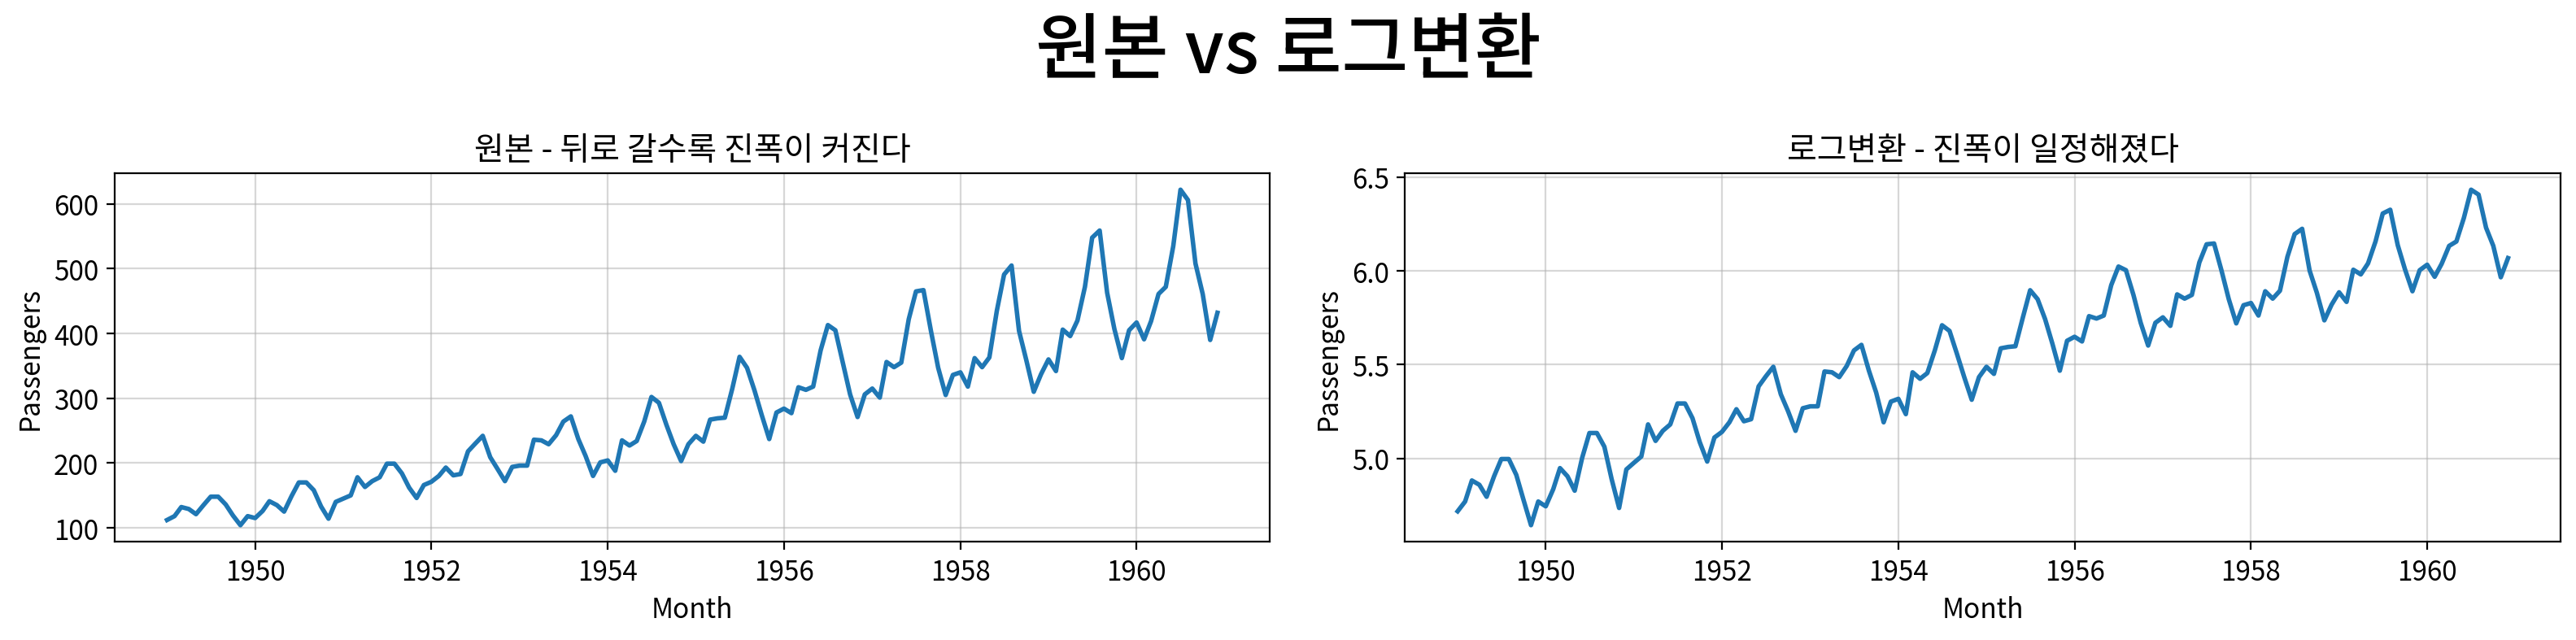

{'대상': '로그변환',
 '관측치 수': 144,
 '검정통계량(ADF)': np.float64(-1.717),
 'p-value': np.float64(0.422),
 '사용 시차': 13,
 '1% 기각값': np.float64(-3.482),
 '5% 기각값': np.float64(-2.884),
 '10% 기각값': np.float64(-2.579),
 '판정': '비정상'}

In [13]:
fig, ax = my_plot.init(
    rows=1,
    cols=2,
    width=800,
    height=400,
    title="원본 vs 로그변환",
)

my_plot.lineplot(x=df1.index, y=df1["Passengers"], ax=ax[0])
ax[0].set_title("원본 - 뒤로 갈수록 진폭이 커진다")

my_plot.lineplot(x=log_s.index, y=log_s, ax=ax[1])
ax[1].set_title("로그변환 - 진폭이 일정해졌다")

my_plot.show()

# 로그 변환에 대해 ADF 검정 결과
r_log = adf_test(log_s, "로그변환")
r_log

#### 차분(Differencing)의 이해

- 각 관측값과 바로 이전 관측값의 차이
    **얼마인가(수준) 얼마나 변했는가(변화량)**로 바꾸는 것

$$
\Delta y_t = y_t - y_{t-1}
$$
- 예: 1949년 2월 승객 118명, 1월 승객 112명
$$
\text{1차 차분값} = 118 - 112 = +6
$$

| 차분 전 | 차분 후 |
|---|---|
| 이번 달 승객은 432명이다. | 이번 달 승객은 지난달보다 30명 줄었다. |
| 계속 커지므로 평균이 일정하지 않다. | 증감은 0 주변을 맴돌아 평균이 일정해진다. |


> **주의:** 차분하면 해석의 단위가 바뀐다. 예측한 값은 **“승객 수”**가 아니라 **“승객 수의 변화량”**이다.
>
> **첫 번째 값은 이전 값이 없어 결측치가 발생한다.**  
> 원본이 144개이면 1차 차분 결과는 143개이다.

### 3. 차분 수행

In [14]:
# 차분 수행 --> 차분의 결과로 발생하는 결측치는 제거한다.
df2 = df1.diff().dropna()

print(f"원본 {len(df1)}개 → 1차 차분 {len(df2)}개 (첫 행 소실)")
df2.head()

원본 144개 → 1차 차분 143개 (첫 행 소실)


,Passengers
Month,
1949-02-01,6.000
1949-03-01,14.000
1949-04-01,-3.000
1949-05-01,-8.000
1949-06-01,14.000


### 4. 차분 결과 시각화 및 ADF 검정

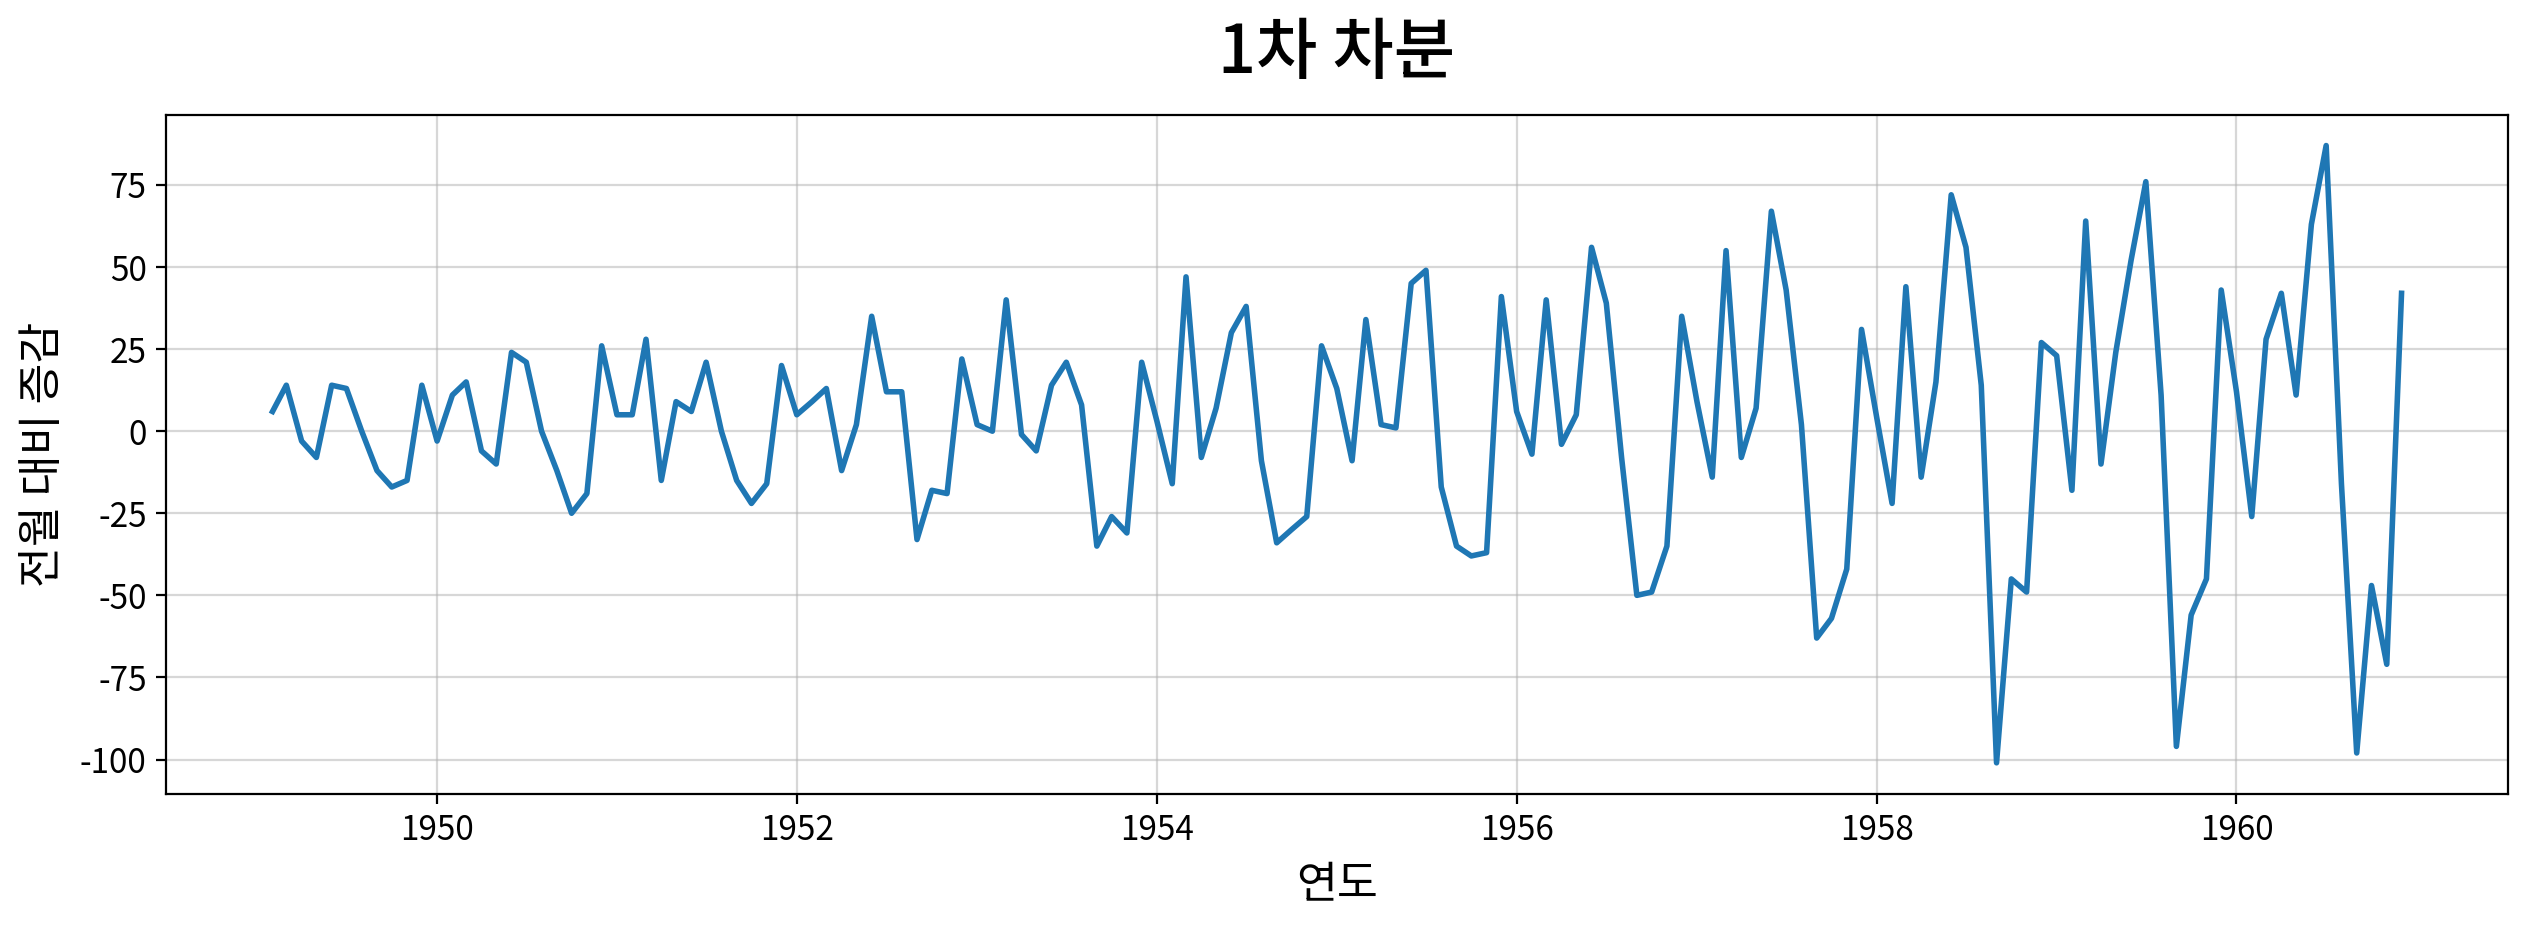

대상            1차 차분
관측치 수           143
검정통계량(ADF)   -2.829
p-value       0.054
사용 시차            12
1% 기각값       -3.482
5% 기각값       -2.884
10% 기각값      -2.579
판정              비정상
dtype: object

In [15]:
my_plot.lineplot(
    data=df2,
    x=df2.index,
    y="Passengers",
    title="1차 차분",
    xlabel="연도",
    ylabel="전월 대비 증감",
    width=1280,
    height=480,
)

r_d1 = adf_test(df2["Passengers"], "1차 차분")

Series(r_d1)

![alt text](image-23.png)

### 5. 2차 차분 실험
- 차분을 한번 더 해보고, 차수별로 표준화가 어떻게 변하는지 관찰한다.

In [16]:
over_diff = []                  # 차분 횟수별 ADF 검정 결과를 담을 리스트
tmp = df1["Passengers"].copy()  # 원본 데이터를 복사하여 차분 수행

for i in range(4):              # 0차 ~ 3차 차분까지 반복
    r = adf_test(tmp, f"{i}차 차분" if i > 0 else "원본")  # ADF 검정 수행
    r["표준편차"] = round(tmp.std(), 2)                    # 표준편차 계산
    over_diff.append(r)                                     # 결과를 리스트에 추가
    tmp = tmp.diff().dropna()  # 다음 차분을 위해 1차 차분 수행 후 결측치 제거

DataFrame(over_diff)[
    ["대상", "관측치 수", "검정통계량(ADF)", "p-value", "판정", "표준편차"]
]

,대상,관측치 수,검정통계량(ADF),p-value,판정,표준편차
0,원본,144,0.815,0.992,비정상,119.970
1,1차 차분,143,-2.829,0.054,비정상,33.750
2,2차 차분,142,-16.384,0.000,정상,39.860
3,3차 차분,141,-9.435,0.000,정상,60.980


![alt text](image-24.png)

### 6. 계절차분(Seasonal Differencing)
![alt text](image-25.png)

- pandas에서는 diff(12)로 간단히 수행한다. 앞의 12개 행이 결측치가 된다.

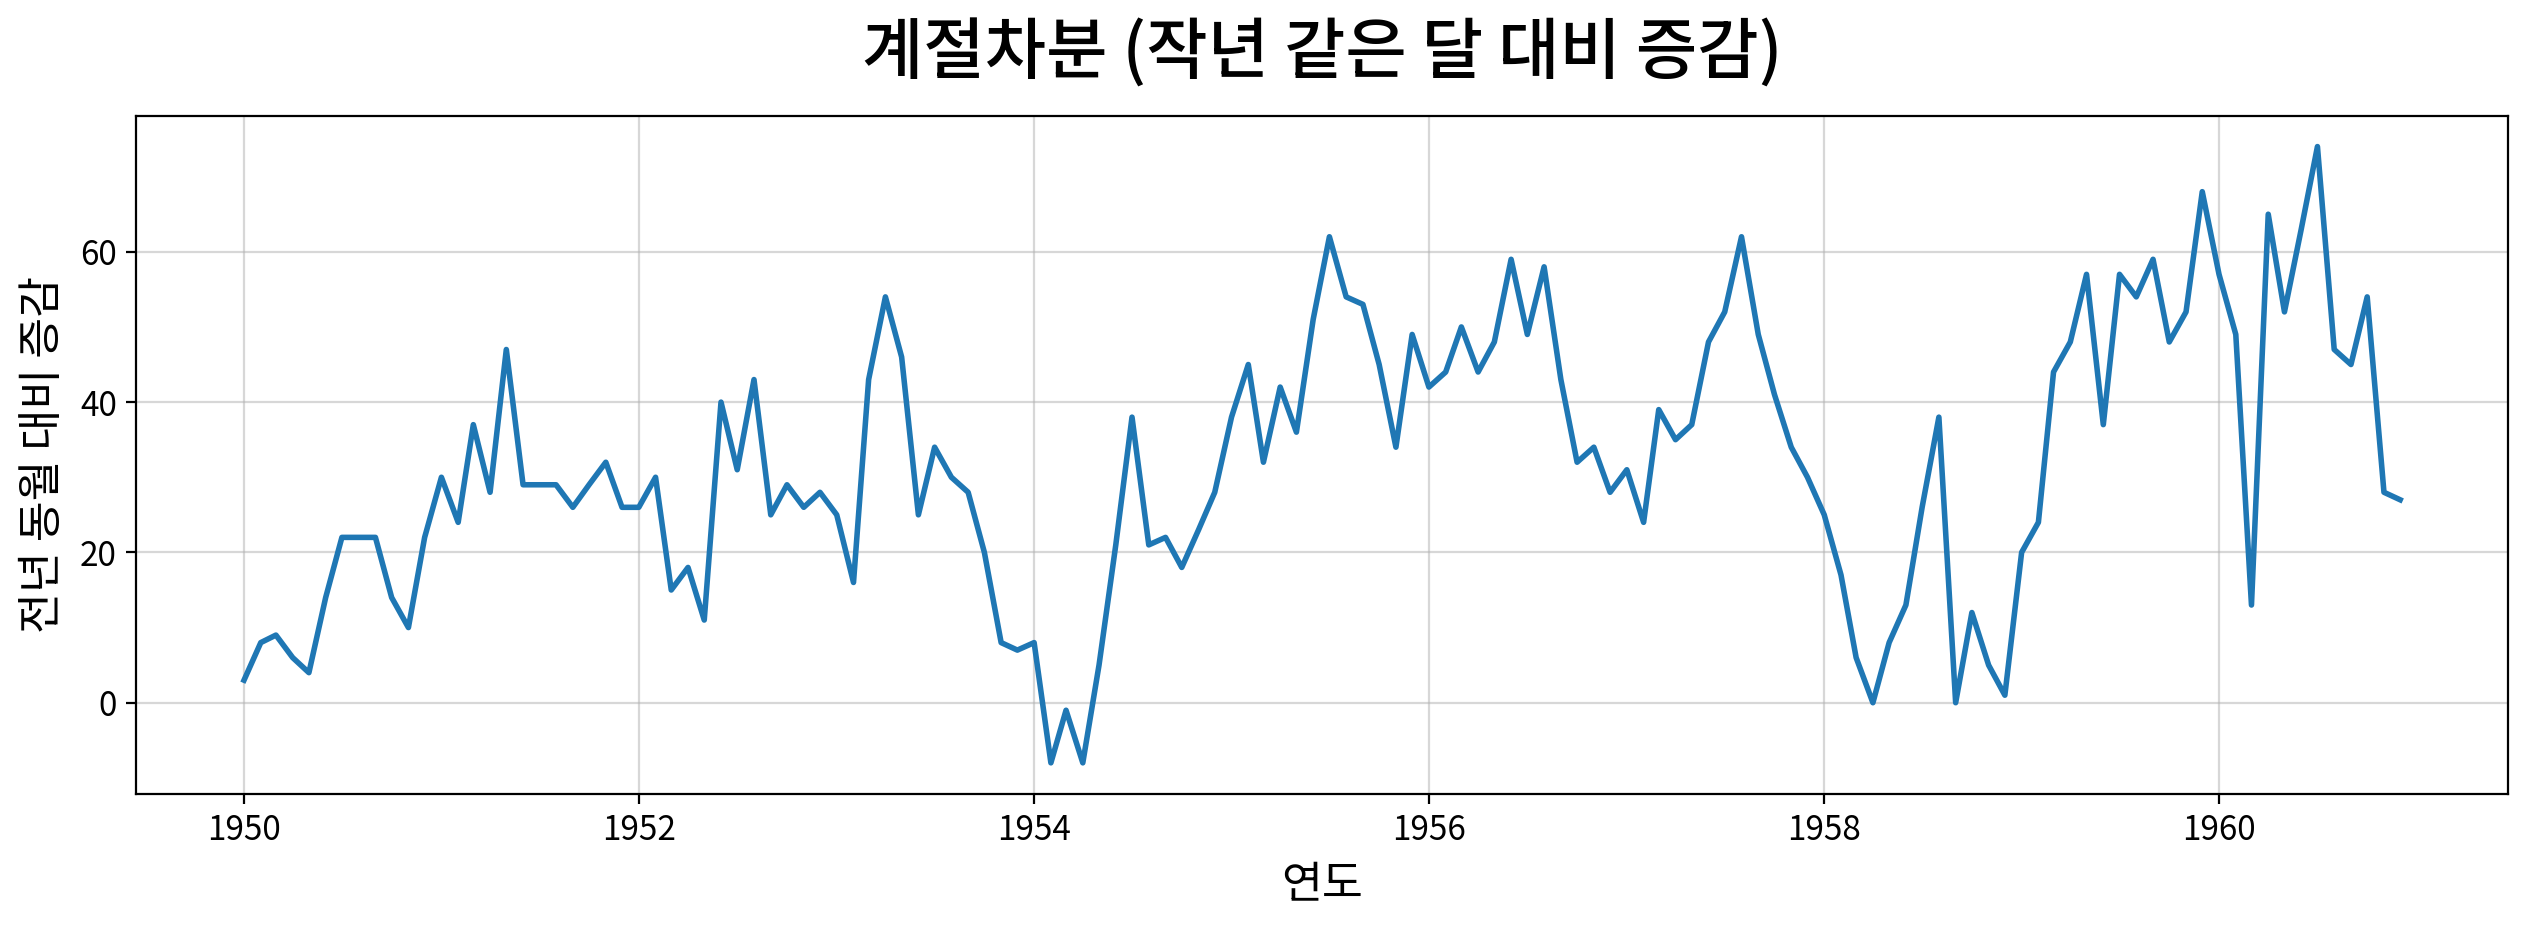

대상            계절차분(12)
관측치 수              132
검정통계량(ADF)      -3.383
p-value          0.012
사용 시차                1
1% 기각값          -3.482
5% 기각값          -2.884
10% 기각값         -2.579
판정                  정상
dtype: object

In [17]:
df3 = df1["Passengers"].diff(12).dropna()

my_plot.lineplot(
    x=df3.index,
    y=df3,
    title="계절차분 (작년 같은 달 대비 증감)",
    xlabel="연도",
    ylabel="전년 동월 대비 증감",
    width=1280,
    height=480,
)

r_ds = adf_test(df3, "계절차분(12)")  # ADF 검정 수행
Series(r_ds)

## #06. 전처리 조합 비교 - 무엇을 쓸 것인가?
### 1. 전처리 파이프라인
- 지금까지 배운 세 가지 도구(로그변환/ 일반차분/계절차분)를 조합해 한꺼번에 비교한다.
    - 조합을 딕셔너리 하나로 정의해두고 반복문으로 검정만 돌리면된다.
    - diff()가 일반차분, diff(12)가 계절차분이므로 메서드를 이어붙이면 그대로 조합이 된다.

In [18]:
s = df1["Passengers"]
ls = np.log(s)

combos = {
    "① 원본": s,
    "② 1차 차분": s.diff(),
    "③ 2차 차분": s.diff().diff(),
    "④ 로그변환": ls,
    "⑤ 로그 + 1차 차분": ls.diff(),
    "⑥ 계절차분(12)": s.diff(12),
    "⑦ 로그 + 계절차분(12)": ls.diff(12),
    "⑧ 로그 + 1차 차분 + 계절차분(12)": ls.diff().diff(12),
}

### 2. 조합 비교

In [19]:
report = []  # ADF 검정 결과를 담을 리스트

for name, x in combos.items():  # combos 딕셔너리의 key, value를 순회
    r = adf_test(x, name)  # ADF 검정 수행
    r["표준편차"] = round(x.dropna().std(), 3)  # 표준편차 계산
    report.append(r)  # 결과를 리스트에 추가

# ADF 검정 결과를 데이터프레임으로 변환하여 출력
DataFrame(report)[
    ["대상", "관측치 수", "검정통계량(ADF)", "p-value", "5% 기각값", "표준편차", "판정"]
]

,대상,관측치 수,검정통계량(ADF),p-value,5% 기각값,표준편차,판정
0,① 원본,144,0.815,0.992,-2.884,119.966,비정상
1,② 1차 차분,143,-2.829,0.054,-2.884,33.754,비정상
2,③ 2차 차분,142,-16.384,0.000,-2.884,39.856,정상
3,④ 로그변환,144,-1.717,0.422,-2.884,0.441,비정상
4,⑤ 로그 + 1차 차분,143,-2.717,0.071,-2.884,0.107,비정상
5,⑥ 계절차분(12),132,-3.383,0.012,-2.884,17.655,정상
6,⑦ 로그 + 계절차분(12),132,-2.710,0.072,-2.886,0.062,비정상
7,⑧ 로그 + 1차 차분 + 계절차분(12),131,-4.443,0.000,-2.886,0.046,정상


![alt text](image-26.png)

## #07. 모듈화 기능 확인
### 1. 데이터 로딩 후 시계열 인덱스 설정

In [20]:
origin = load_data('air_passengers')

# 날짜 컬럼명만 알려주면 된다
df = my_ts.set_index(origin, 'Month')

print('인덱스 타입:', type(df.index))

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
인덱스 타입: <class 'pandas.DatetimeIndex'>


### 2. 구간별 비교

In [21]:
# 구간을 3개로 나눠 비교
my_ts.report_split(df, 'Passengers', size=3)

,시작,종료,관측치 수,평균,표준편차,변동계수
구간,,,,,,
구간 1,1949-01-01,1952-12-01,48,158.375,33.086,0.209
구간 2,1953-01-01,1956-12-01,48,269.042,55.731,0.207
구간 3,1957-01-01,1960-12-01,48,413.479,78.498,0.190


### 3. 기간별 비교

In [22]:
# 연도별로 묶어 변동폭 비교
# freq = "YE" -> 연말 기준 1년씩 / QE -> 분기씩 / ME -> 월말 기준 한달씩 / WE -> 주말 기준 1주일씩 / D -> 하루씩
my_ts.report_variation(df, 'Passengers', freq='YE')

표준편차 최대/최소: 5.67배
변동계수 최대/최소: 1.56배
판정: 변동폭이 수준에 비례한다 → 로그변환 권장 / 승법(multiplicative) 모델


,평균,표준편차,변동계수
기간,,,
1949-12-31,126.667,13.720,0.108
1950-12-31,139.667,19.071,0.137
1951-12-31,170.167,18.438,0.108
1952-12-31,197.000,22.966,0.117
1953-12-31,225.000,28.467,0.127
1954-12-31,238.917,34.924,0.146
1955-12-31,284.000,42.140,0.148
1956-12-31,328.250,47.862,0.146
1957-12-31,368.417,57.891,0.157


### 4. ADF 검정

In [23]:
my_ts.adf_test(df, 'Passengers')

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
Passengers,144,0.815,0.992,13,-3.482,-2.884,-2.579,119.966,False,비정상


### 5. 시계열 데이터 변환

In [24]:
# 로그 변환 -> 1차 차분 -> 계절 차분(12)을 한번에 적용한다
log_diff = my_ts.transform(df, 'Passengers', log=True, diff=1, seasonal_diff=1, period=12)

# 변환 결과에 대한 ADF 검정 수행
my_ts.adf_test(log_diff, name='로그 + 1차 차분 + 계절차분(12)')

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
로그 + 1차 차분 + 계절차분(12),131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상


### 6. 최적 차분 회수 판정

In [25]:
# 차수를 늘려가며 검정한다. 표준편차가 최소인 차수에 *가 찍힌다.
my_ts.adf_diff(df, 'Passengers',  max_diff=3)

권장 차분 차수: 1차 차분 (표준편차가 최소인 지점)
⚠️ 1차 차분은 아직 비정상입니다(p-value 0.0542). 차분을 더 늘리지 말고 로그변환·계절차분으로 남은 구조를 처리하세요. → adf_transform()


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정,권장
원본,144,0.815,0.992,13,-3.482,-2.884,-2.579,119.966,False,비정상,
1차 차분,143,-2.829,0.054,12,-3.482,-2.884,-2.579,33.754,False,비정상,★ 여기까지
2차 차분,142,-16.384,0.000,11,-3.482,-2.884,-2.579,39.856,True,정상,과대차분
3차 차분,141,-9.435,0.000,14,-3.483,-2.885,-2.579,60.984,True,정상,과대차분


### 7. 자동 전치리 및 결과 검정

In [26]:
# 로그 여부(2) x 일반차분 0~2회(3) x 계절차분 0~1회(2) = 12가지 조합을 자동 생성해 검정한다
result = my_ts.adf_transform(df, 'Passengers', period=12, max_diff=2)
result

조합 12개 중 정상 7개
권장 전처리: 로그변환 + 1차 차분 + 계절차분(12)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
로그변환 + 1차 차분 + 계절차분(12),131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상
로그변환 + 2차 차분 + 계절차분(12),130,-4.305,0.000,10,-3.487,-2.886,-2.580,0.075,True,정상
로그변환 + 2차 차분,142,-8.197,0.000,13,-3.483,-2.884,-2.579,0.135,True,정상
1차 차분 + 계절차분(12),131,-15.596,0.000,0,-3.482,-2.884,-2.579,12.357,True,정상
계절차분(12),132,-3.383,0.012,1,-3.482,-2.884,-2.579,17.655,True,정상
2차 차분 + 계절차분(12),130,-8.098,0.000,7,-3.485,-2.886,-2.580,20.072,True,정상
2차 차분,142,-16.384,0.000,11,-3.482,-2.884,-2.579,39.856,True,정상
로그변환 + 계절차분(12),132,-2.710,0.072,12,-3.487,-2.886,-2.580,0.062,False,비정상
로그변환 + 1차 차분,143,-2.717,0.071,14,-3.483,-2.884,-2.579,0.107,False,비정상
로그변환,144,-1.717,0.422,13,-3.482,-2.884,-2.579,0.441,False,비정상


Month
1950-02-01    0.039
1950-03-01    0.000
1950-04-01   -0.020
1950-05-01   -0.013
1950-06-01    0.066
              ...  
1960-08-01   -0.046
1960-09-01    0.012
1960-10-01    0.032
1960-11-01   -0.050
1960-12-01   -0.010
Name: 로그변환 + 1차 차분 + 계절차분(12), Length: 131, dtype: float64